In [1]:
# STEP 1 — EfficientNetV2B0 Eye Disease Classification

# This notebook trains an EfficientNetV2B0 transfer-learning model
# for 5-class retinal fundus image classification.

# Pipeline:

# Dataset
# → Image Verification
# → Preprocessing
# → Data Augmentation
# → EfficientNetV2B0
# → Transfer Learning
# → Fine-Tuning
# → Evaluation
# → Confusion Matrix
# → Misclassification Analysis
# → Model Saving

In [2]:
# STEP 2 — Imports

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("Keras:", getattr(keras, "__version__", "unknown"))

TensorFlow: 2.21.0
Keras: 3.15.1


In [3]:
# STEP 3 — Reproducibility and GPU setup

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

AUTOTUNE = tf.data.AUTOTUNE

GPUs: []


In [4]:
# STEP 4 — Project paths

# This notebook is expected to be inside: Disease Detection/notebooks/

PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / "preprocessing" / "splits").exists():
    PROJECT_ROOT = Path.cwd()

SPLIT_DIR = PROJECT_ROOT / "preprocessing" / "splits"
MODEL_DIR = PROJECT_ROOT / "model"
REPORT_DIR = PROJECT_ROOT / "reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV = SPLIT_DIR / "validation.csv"
TEST_CSV = SPLIT_DIR / "test.csv"

BEST_MODEL_PATH = MODEL_DIR / "efficientnetv2_best.keras"
FINETUNED_MODEL_PATH = MODEL_DIR / "efficientnetv2_finetuned_best.keras"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_CSV:", TRAIN_CSV)
print("VAL_CSV:", VAL_CSV)
print("TEST_CSV:", TEST_CSV)

PROJECT_ROOT: d:\Practice Projects\Disease Detection
TRAIN_CSV: d:\Practice Projects\Disease Detection\preprocessing\splits\train.csv
VAL_CSV: d:\Practice Projects\Disease Detection\preprocessing\splits\validation.csv
TEST_CSV: d:\Practice Projects\Disease Detection\preprocessing\splits\test.csv


In [5]:
# STEP 5 — Configuration

IMG_SIZE = (224, 224)
IMAGE_HEIGHT, IMAGE_WIDTH = IMG_SIZE

BATCH_SIZE = 16
NUM_CLASSES = 5

INITIAL_EPOCHS = 20
FINE_TUNE_EPOCHS = 40

INITIAL_LR = 1e-3
FINE_TUNE_LR = 1e-5

DROPOUT = 0.35

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: (224, 224)
Batch size: 16
Number of classes: 5


In [6]:
# STEP 6 — Load the existing split CSV files

assert TRAIN_CSV.exists(), f"Missing: {TRAIN_CSV}"
assert VAL_CSV.exists(), f"Missing: {VAL_CSV}"
assert TEST_CSV.exists(), f"Missing: {TEST_CSV}"

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain columns:", train_df.columns.tolist())

Train: (1260, 2)
Validation: (270, 2)
Test: (270, 2)

Train columns: ['image_path', 'label']


In [7]:
# STEP 7 — Detect and normalize the path/label columns

def find_column(df, candidates):
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    return None

PATH_CANDIDATES = [
    "filepath", "file_path", "image_path", "path",
    "filename", "file_name", "image", "image_name"
]

LABEL_CANDIDATES = [
    "label", "class", "target", "category", "disease"
]

PATH_COL = find_column(train_df, PATH_CANDIDATES)
LABEL_COL = find_column(train_df, LABEL_CANDIDATES)

if PATH_COL is None or LABEL_COL is None:
    raise ValueError(
        f"Could not identify path/label columns. "
        f"Found columns: {train_df.columns.tolist()}"
    )

print("Detected path column:", PATH_COL)
print("Detected label column:", LABEL_COL)

for df in (train_df, val_df, test_df):
    df[PATH_COL] = df[PATH_COL].astype(str).str.strip()
    df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="raise").astype(int)

Detected path column: image_path
Detected label column: label


In [8]:
# STEP 8 — Resolve image paths without changing the existing CSV structure

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def resolve_image_path(value):
    raw = Path(str(value))

    candidates = [
        raw,
        PROJECT_ROOT / raw,
        PROJECT_ROOT / "dataset" / raw,
        PROJECT_ROOT / "datasets" / raw,
        PROJECT_ROOT / "preprocessing" / raw,
    ]

    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return str(candidate.resolve())

    # If the CSV contains only a filename, search the project once.
    name = raw.name
    matches = []
    for root in [PROJECT_ROOT / "dataset", PROJECT_ROOT / "datasets"]:
        if root.exists():
            matches.extend(root.rglob(name))

    if matches:
        return str(matches[0].resolve())

    return str(raw)

for df in (train_df, val_df, test_df):
    df["resolved_path"] = df[PATH_COL].map(resolve_image_path)

def count_missing(df):
    return sum(not Path(p).exists() for p in df["resolved_path"])

print("Missing train images:", count_missing(train_df))
print("Missing validation images:", count_missing(val_df))
print("Missing test images:", count_missing(test_df))

if any(count_missing(df) > 0 for df in (train_df, val_df, test_df)):
    raise FileNotFoundError(
        "Some CSV image paths cannot be resolved. "
        "Check the path column in the split CSV files before training."
    )

Missing train images: 0
Missing validation images: 0
Missing test images: 0


In [9]:
# STEP 9 — Verify label mapping

all_labels = sorted(
    set(train_df[LABEL_COL].unique())
    | set(val_df[LABEL_COL].unique())
    | set(test_df[LABEL_COL].unique())
)

print("Detected labels:", all_labels)

if all_labels != list(range(NUM_CLASSES)):
    raise ValueError(
        f"Expected labels 0..{NUM_CLASSES-1}, but found {all_labels}. "
        "Do not train until the split CSV label mapping is corrected."
    )

# Keep numeric labels until the exact dataset mapping is confirmed.
CLASS_NAMES = {
    0: "Class 0",
    1: "Class 1",
    2: "Class 2",
    3: "Class 3",
    4: "Class 4",
}

print("\nClass mapping:")
for label, name in CLASS_NAMES.items():
    print(f"{label} -> {name}")

Detected labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Class mapping:
0 -> Class 0
1 -> Class 1
2 -> Class 2
3 -> Class 3
4 -> Class 4


In [10]:
# STEP 10 — Check class distribution

print("Training Class Distribution:")
print(train_df[LABEL_COL].value_counts().sort_index())

print("\nValidation Class Distribution:")
print(val_df[LABEL_COL].value_counts().sort_index())

print("\nTest Class Distribution:")
print(test_df[LABEL_COL].value_counts().sort_index())

expected_train = train_df[LABEL_COL].value_counts().sort_index()
expected_val = val_df[LABEL_COL].value_counts().sort_index()
expected_test = test_df[LABEL_COL].value_counts().sort_index()

print("\nBalanced train:", expected_train.nunique() == 1)
print("Balanced validation:", expected_val.nunique() == 1)
print("Balanced test:", expected_test.nunique() == 1)

Training Class Distribution:
label
0    252
1    252
2    252
3    252
4    252
Name: count, dtype: int64

Validation Class Distribution:
label
0    54
1    54
2    54
3    54
4    54
Name: count, dtype: int64

Test Class Distribution:
label
0    54
1    54
2    54
3    54
4    54
Name: count, dtype: int64

Balanced train: True
Balanced validation: True
Balanced test: True


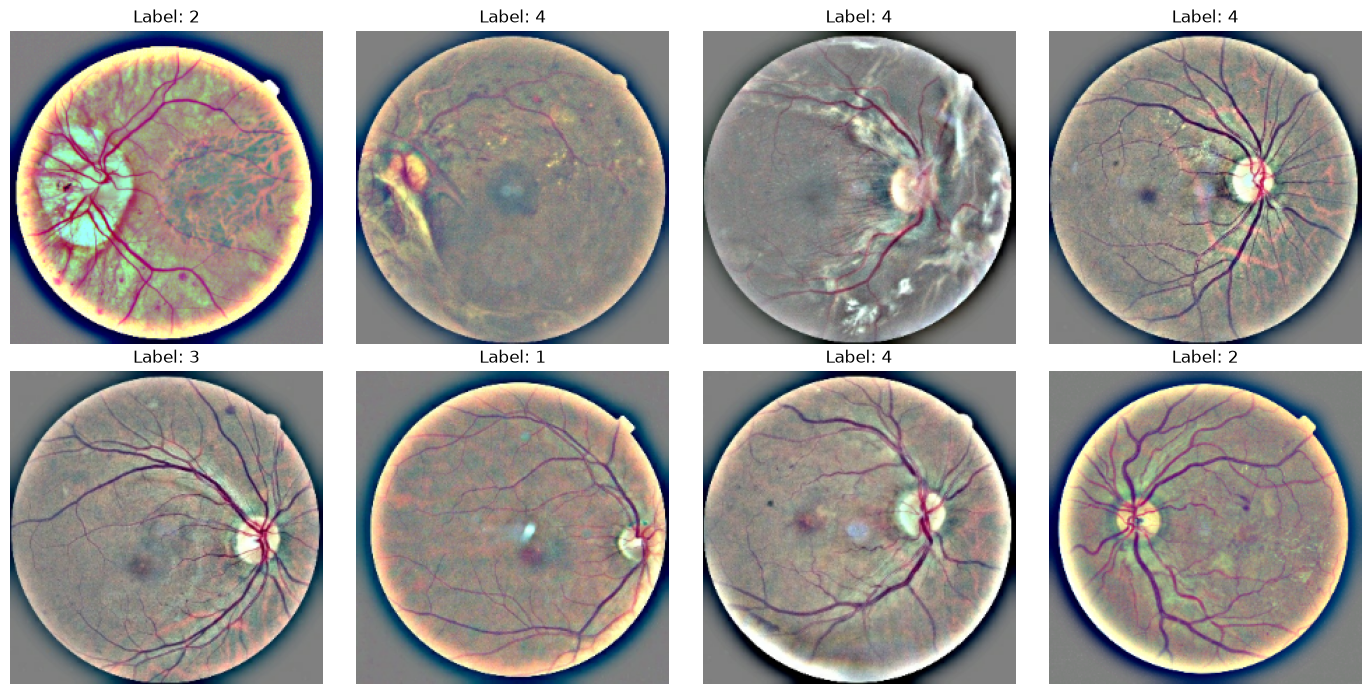

In [11]:
# STEP 11 — Inspect a few source images before creating tf.data pipelines

def read_image_for_check(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32)

sample_df = train_df.sample(min(8, len(train_df)), random_state=SEED)

plt.figure(figsize=(14, 7))
for i, (_, row) in enumerate(sample_df.iterrows()):
    img = read_image_for_check(row["resolved_path"]).numpy()
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.clip(img, 0, 255).astype(np.uint8))
    plt.title(f"Label: {row[LABEL_COL]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# STEP 12 — Build the image loader

def load_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.image.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE,
        method=tf.image.ResizeMethod.BILINEAR
    )

    # IMPORTANT:
    # Keep values in 0..255.
    # EfficientNetV2's built-in preprocessing handles normalization.
    image = tf.cast(image, tf.float32)

    label = tf.cast(label, tf.int32)
    return image, label

In [13]:
# STEP 13 — Create tf.data datasets

def make_dataset(df, training=False):
    paths = df["resolved_path"].values
    labels = df[LABEL_COL].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print(train_ds)
print(val_ds)
print(test_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [14]:
# STEP 14 — Verify the actual pixel range entering the model

x_batch, y_batch = next(iter(train_ds))

print("Batch shape:", x_batch.shape)
print("Label shape:", y_batch.shape)
print("Pixel min:", float(tf.reduce_min(x_batch)))
print("Pixel max:", float(tf.reduce_max(x_batch)))
print("Pixel mean:", float(tf.reduce_mean(x_batch)))

assert float(tf.reduce_min(x_batch)) >= 0
assert float(tf.reduce_max(x_batch)) <= 255.0 + 1e-3

Batch shape: (16, 224, 224, 3)
Label shape: (16,)
Pixel min: 0.0
Pixel max: 255.0
Pixel mean: 134.58123779296875


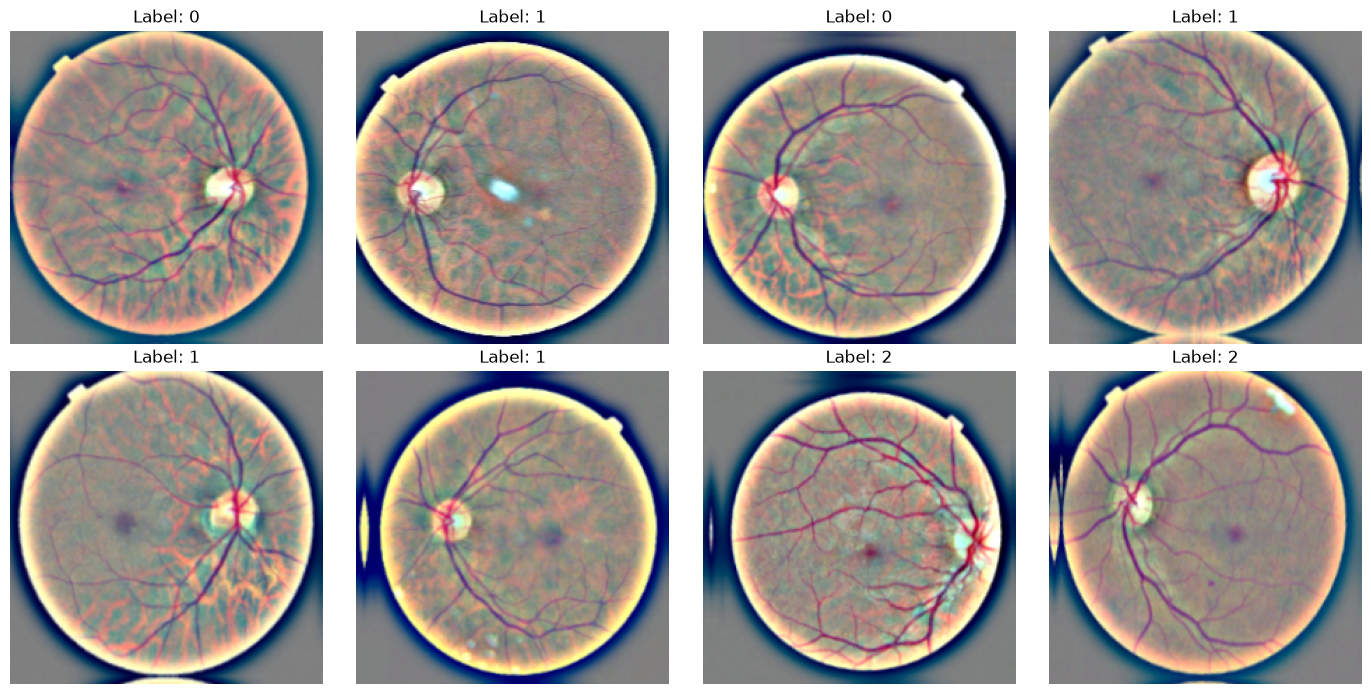

In [15]:
# STEP 15 — Data augmentation

augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.03, fill_mode="reflect", seed=SEED),
        layers.RandomZoom(
            height_factor=(-0.08, 0.08),
            width_factor=(-0.08, 0.08),
            fill_mode="reflect",
            seed=SEED,
        ),
        layers.RandomTranslation(
            height_factor=0.03,
            width_factor=0.03,
            fill_mode="reflect",
            seed=SEED,
        ),
        layers.RandomContrast(0.10, seed=SEED),
    ],
    name="fundus_augmentation",
)

# Visualization only — augmentation is active during training.
augmented_preview = augmentation(x_batch[:8], training=True)

plt.figure(figsize=(14, 7))
for i in range(min(8, len(augmented_preview))):
    img = augmented_preview[i].numpy()
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.clip(img, 0, 255).astype(np.uint8))
    plt.title(f"Label: {int(y_batch[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# STEP 16 — Build the EfficientNetV2B0 transfer-learning model

inputs = keras.Input(
    shape=(*IMG_SIZE, 3),
    name="fundus_image"
)

x = augmentation(inputs)

# IMPORTANT:
# EfficientNetV2 includes its own preprocessing.
# Keep image values in the 0–255 range.
# DO NOT divide x by 255 before this backbone.

backbone = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    include_preprocessing=True
)

backbone.trainable = False

x = backbone(x, training=False)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.BatchNormalization(
    name="classifier_bn"
)(x)

x = layers.Dropout(
    DROPOUT,
    name="classifier_dropout"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="disease_output"
)(x)

model = keras.Model(
    inputs,
    outputs,
    name="EfficientNetV2B0_EyeDisease"
)

# Store the actual Keras backbone layer name.
# This avoids hard-coding "efficientnetv2b0".
BACKBONE_LAYER_NAME = backbone.name

print("Backbone layer name:", BACKBONE_LAYER_NAME)

model.summary()

Backbone layer name: efficientnetv2-b0


Model: "EfficientNetV2B0_EyeDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fundus_image (InputLayer)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fundus_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_bn                   │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disease_output (Dense)          │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,930,837 (22.62 MB)

 Trainable params: 8,965 (35.02 KB)

 Non-trainable params: 5,921,872 (22.59 MB)

In [17]:
# STEP 17 — Compile the frozen-backbone model

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ],
)

print("Model compiled.")

Model compiled.


In [18]:
# STEP 18 — Callbacks for stable training

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
]

In [19]:
# STEP 19 — Initial transfer-learning training

history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.3794 - loss: 1.6566
Epoch 1: val_accuracy improved from None to 0.39259, saving model to d:\Practice Projects\Disease Detection\model\efficientnetv2_best.keras

Epoch 1: finished saving model to d:\Practice Projects\Disease Detection\model\efficientnetv2_best.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 49s 472ms/step - accuracy: 0.3794 - loss: 1.6566 - val_accuracy: 0.3926 - val_loss: 1.3477 - learning_rate: 0.0010
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.4881 - loss: 1.3299
Epoch 2: val_accuracy improved from 0.39259 to 0.47037, saving model to d:\Practice Projects\Disease Detection\model\efficientnetv2_best.keras

Epoch 2: finished saving model to d:\Practice Projects\Disease Detection\model\efficientnetv2_best.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 501ms/step - accuracy: 0.4881 - loss: 1.3299 - val_accuracy: 0.4704 - val_loss: 1.2344 - learning_rate: 0.0010
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accura

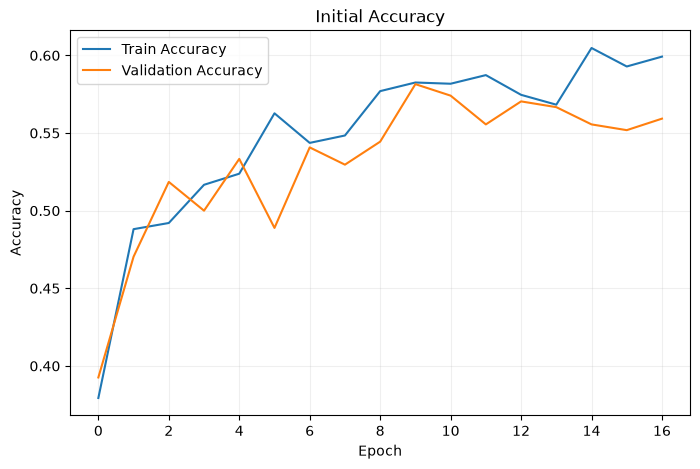

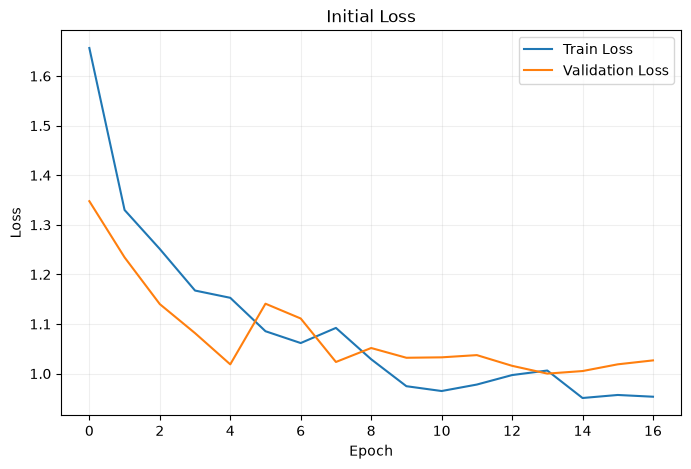

In [20]:
# STEP 20 — Plot initial training history

def plot_history(history, title_prefix="Training"):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="Train Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

plot_history(history_initial, "Initial")

In [21]:
# STEP 21 — Load the best frozen-backbone checkpoint

if BEST_MODEL_PATH.exists():
    model = keras.models.load_model(BEST_MODEL_PATH)
    print("Loaded:", BEST_MODEL_PATH)
else:
    print("Best checkpoint not found; continuing with current model.")

Loaded: d:\Practice Projects\Disease Detection\model\efficientnetv2_best.keras


In [30]:
# STEP 22 — Fine-tuning setup

# Load the actual EfficientNetV2 backbone.
backbone = model.get_layer(BACKBONE_LAYER_NAME)

# Allow fine-tuning.
backbone.trainable = True

# Freeze the first 70% of backbone layers.
# Only the final 30% will adapt to retinal disease features.
fine_tune_from = int(len(backbone.layers) * 0.70)

for layer in backbone.layers[:fine_tune_from]:
    layer.trainable = False

# Keep BatchNormalization layers frozen because
# the dataset is relatively small.
for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(
    layer.trainable for layer in backbone.layers
)

print("Total backbone layers:", len(backbone.layers))
print("Frozen backbone layers:", fine_tune_from)
print("Trainable backbone layers:", trainable_count)

Total backbone layers: 270
Frozen backbone layers: 189
Trainable backbone layers: 64


In [32]:
# STEP 23 — Compile for low-learning-rate fine-tuning

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ],
)

fine_tune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(FINETUNED_MODEL_PATH),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
]

In [33]:
# STEP 24 — Fine-tune the model

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks,
    verbose=1,
)

Epoch 1/40
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.5817 - loss: 0.9679
Epoch 1: val_accuracy improved from None to 0.56667, saving model to d:\Practice Projects\Disease Detection\model\efficientnetv2_finetuned_best.keras

Epoch 1: finished saving model to d:\Practice Projects\Disease Detection\model\efficientnetv2_finetuned_best.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 94s 903ms/step - accuracy: 0.5817 - loss: 0.9679 - val_accuracy: 0.5667 - val_loss: 1.0602 - learning_rate: 1.0000e-05
Epoch 2/40
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.5849 - loss: 0.9621
Epoch 2: val_accuracy did not improve from 0.56667
79/79 ━━━━━━━━━━━━━━━━━━━━ 49s 617ms/step - accuracy: 0.5849 - loss: 0.9621 - val_accuracy: 0.5407 - val_loss: 1.0664 - learning_rate: 1.0000e-05
Epoch 3/40
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.5929 - loss: 0.9781
Epoch 3: val_accuracy did not improve from 0.56667
79/79 ━━━━━━━━━━━━━━━━━━━━ 47s 601ms/step - accuracy: 0.5929 - loss: 0.9781 - val_

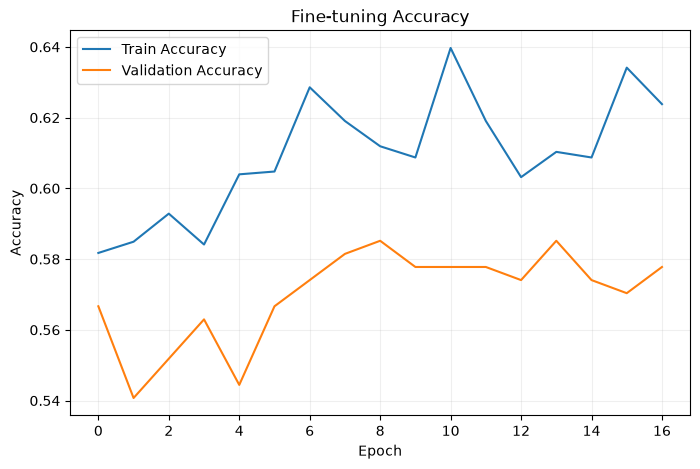

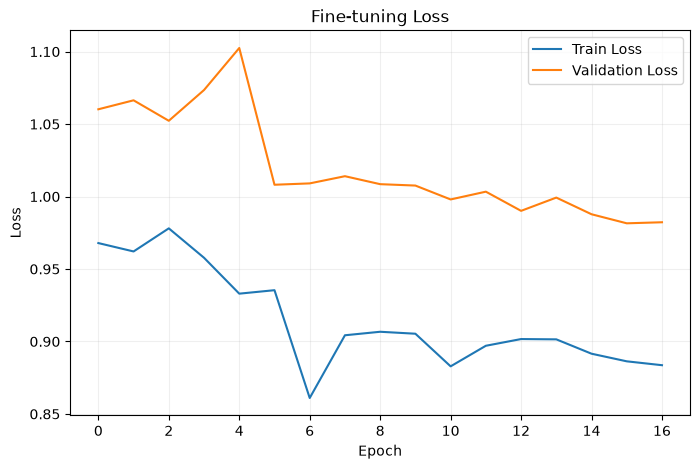

In [34]:
# STEP 25 — Plot fine-tuning history

plot_history(history_finetune, "Fine-tuning")

In [35]:
# STEP 26 — Load the best final model and evaluate

if FINETUNED_MODEL_PATH.exists():
    final_model = keras.models.load_model(FINETUNED_MODEL_PATH)
    print("Loaded fine-tuned checkpoint:", FINETUNED_MODEL_PATH)
elif BEST_MODEL_PATH.exists():
    final_model = keras.models.load_model(BEST_MODEL_PATH)
    print("Loaded initial best checkpoint:", BEST_MODEL_PATH)
else:
    final_model = model
    print("Using current model.")

test_loss, test_accuracy = final_model.evaluate(test_ds, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Loaded fine-tuned checkpoint: d:\Practice Projects\Disease Detection\model\efficientnetv2_finetuned_best.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 254ms/step - accuracy: 0.5444 - loss: 1.0667
Test Loss: 1.0667
Test Accuracy: 0.5444


In [37]:
# STEP 27 — Generate predictions for classification report

true_labels = []
pred_labels = []

for images, labels in test_ds:

    predictions = final_model.predict(images, verbose=0)

    # Test labels are already class numbers: 0, 1, 2, 3, 4
    labels_np = labels.numpy()

    if labels_np.ndim == 1:
        true_labels.extend(labels_np.astype(int))
    else:
        true_labels.extend(np.argmax(labels_np, axis=1))

    # Model predictions are probabilities
    pred_labels.extend(np.argmax(predictions, axis=1))

true_labels = np.array(true_labels, dtype=int)
pred_labels = np.array(pred_labels, dtype=int)

print("Prediction analysis completed.")
print("Total test images:", len(true_labels))
print("True labels:", true_labels.shape)
print("Predicted labels:", pred_labels.shape)

Prediction analysis completed.
Total test images: 270
True labels: (270,)
Predicted labels: (270,)


In [38]:
# STEP 28 — Classification report

print("Classification Report:")

report = classification_report(
    true_labels,
    pred_labels,
    labels=list(range(NUM_CLASSES)),
    target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    digits=4,
    zero_division=0,
)

print(report)

overall_accuracy = accuracy_score(true_labels, pred_labels)
print("Overall Accuracy:", round(overall_accuracy, 4))

Classification Report:
              precision    recall  f1-score   support

     Class 0     0.6000    0.5556    0.5769        54
     Class 1     0.5385    0.1296    0.2090        54
     Class 2     0.3729    0.8148    0.5116        54
     Class 3     0.7647    0.4815    0.5909        54
     Class 4     0.7273    0.7407    0.7339        54

    accuracy                         0.5444       270
   macro avg     0.6007    0.5444    0.5245       270
weighted avg     0.6007    0.5444    0.5245       270

Overall Accuracy: 0.5444


Confusion Matrix:
[[30  3 21  0  0]
 [14  7 33  0  0]
 [ 6  3 44  1  0]
 [ 0  0 13 26 15]
 [ 0  0  7  7 40]]


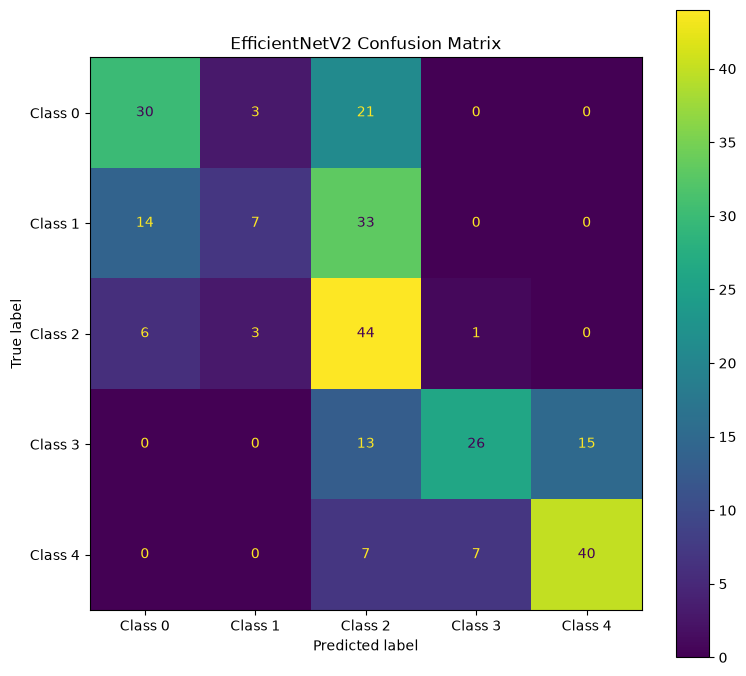

In [40]:
# STEP 29 — Confusion matrix

cm = confusion_matrix(
    true_labels,
    pred_labels,
    labels=list(range(NUM_CLASSES))
)

print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)]
)

disp.plot(
    ax=ax,
    cmap="viridis",
    values_format="d",
    colorbar=True
)

ax.set_title("EfficientNetV2 Confusion Matrix")
plt.tight_layout()
plt.show()


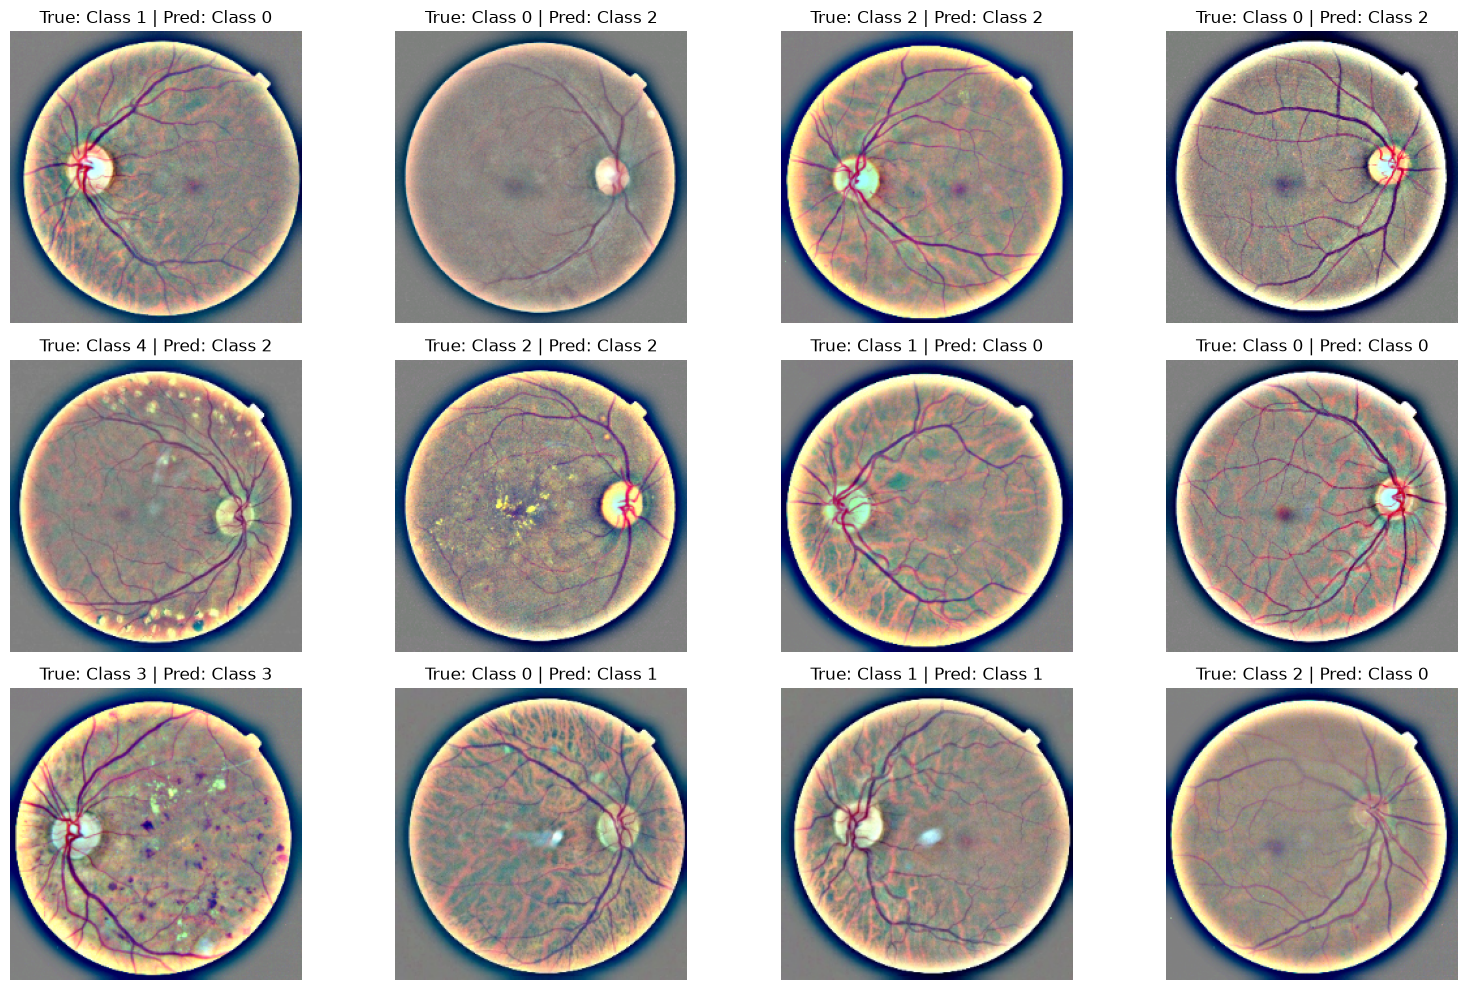

In [41]:
# STEP 30 — Correct image visualization with true/predicted labels

# This fixes the previous clipping warnings:
# images are in 0..255, so convert to uint8 for imshow.

def display_image(img):
    img = np.asarray(img)
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

sample_n = min(12, len(test_df))
sample_indices = np.random.default_rng(SEED).choice(
    len(test_df), size=sample_n, replace=False
)

plt.figure(figsize=(16, 10))

for plot_idx, data_idx in enumerate(sample_indices):
    row = test_df.iloc[data_idx]

    img = read_image_for_check(row["resolved_path"]).numpy()
    true_label = int(true_labels[data_idx])
    pred_label = int(pred_labels[data_idx])

    plt.subplot(3, 4, plot_idx + 1)
    plt.imshow(display_image(img))
    plt.title(
        f"True: {CLASS_NAMES[true_label]} | "
        f"Pred: {CLASS_NAMES[pred_label]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [42]:
# STEP 31 — Per-class error analysis

print("Total Test Images:", len(true_labels))
print("Correct Predictions:", int(np.sum(true_labels == pred_labels)))
print("Incorrect Predictions:", int(np.sum(true_labels != pred_labels)))
print("Overall Accuracy:", float(np.mean(true_labels == pred_labels)))


print("\nIncorrect Predictions by True Class:")

for cls in range(NUM_CLASSES):
    total = int(np.sum(true_labels == cls))
    correct = int(np.sum((true_labels == cls) & (pred_labels == cls)))
    errors = total - correct

    print(
        f"Class {cls}: "
        f"Total={total}, "
        f"Correct={correct}, "
        f"Errors={errors}"
    )

Total Test Images: 270
Correct Predictions: 147
Incorrect Predictions: 123
Overall Accuracy: 0.5444444444444444

Incorrect Predictions by True Class:
Class 0: Total=54, Correct=30, Errors=24
Class 1: Total=54, Correct=7, Errors=47
Class 2: Total=54, Correct=44, Errors=10
Class 3: Total=54, Correct=26, Errors=28
Class 4: Total=54, Correct=40, Errors=14


In [43]:
# STEP 32 — Detailed misclassification analysis

print("Misclassification Analysis:")

for true_cls in range(NUM_CLASSES):
    print(f"\nTrue {CLASS_NAMES[true_cls]}:")

    wrong_predictions = pred_labels[
        (true_labels == true_cls) & (pred_labels != true_cls)
    ]

    if len(wrong_predictions) == 0:
        print("  No misclassifications")
        continue

    unique_pred, counts = np.unique(
        wrong_predictions,
        return_counts=True
    )

    pairs = sorted(
        zip(unique_pred, counts),
        key=lambda x: x[1],
        reverse=True
    )

    for predicted_cls, count in pairs:
        print(
            f"  Predicted as {CLASS_NAMES[int(predicted_cls)]}: "
            f"{int(count)} images"
        )


Misclassification Analysis:

True Class 0:
  Predicted as Class 2: 21 images
  Predicted as Class 1: 3 images

True Class 1:
  Predicted as Class 2: 33 images
  Predicted as Class 0: 14 images

True Class 2:
  Predicted as Class 0: 6 images
  Predicted as Class 1: 3 images
  Predicted as Class 3: 1 images

True Class 3:
  Predicted as Class 4: 15 images
  Predicted as Class 2: 13 images

True Class 4:
  Predicted as Class 2: 7 images
  Predicted as Class 3: 7 images


In [45]:
# STEP 33 – Save test predictions with confidence

import pandas as pd
import numpy as np

true_labels = []
pred_labels = []
pred_probs = []

for images, labels in test_ds:
    predictions = final_model.predict(images, verbose=0)

    true_labels.extend(labels.numpy())
    pred_labels.extend(np.argmax(predictions, axis=1))
    pred_probs.extend(predictions)

true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)
pred_probs = np.array(pred_probs)

pd.DataFrame({
    "true_label": true_labels,
    "predicted_label": pred_labels,
    "confidence": np.max(pred_probs, axis=1),
}).to_csv(
    REPORT_DIR / "efficientnetv2_test_predictions.csv",
    index=False
)

print("Test predictions saved successfully.")
print(f"Total predictions: {len(true_labels)}")

Test predictions saved successfully.
Total predictions: 270
